# <center> ISEL - AA </center>
## <center>Semestre 2024/25 </center>
###  <center> Trabalho 2 - Classificação de Críticas de Cinema do IMDb</center>

Trabalho realizado por:
* Miguel Alcobia, numero <b> 50746 </b>
* Tomás Salvador, numero <b> 50766 </b>
* Rafael Dias, numero <b> 50773 </b>

<b> Turma 51D </b> <br></br>
<b> Docente: Gonçalo Marques </b>

# Imports

In [198]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from typing import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from pydoc import doc
import re
from nltk.stem import SnowballStemmer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

import pickle

# Introdução

Este segundo trabalho tem como objetivo a análise de um conjunto de dados com 50.000 críticas do IMBD, que vêm com a sua respetiva classificação associada. A análise será feita através do treino de um classificador multiclasse e de um regressor para preverem a nota que foi atribuída à crítica. Para estas duas etapas será elaborado um vocabulário para ser possível uma melhor análise das críticas do conjunto de dados.
Por fim, a última tarefa proposta é a realização de clustering para agrupar dados segundo um tópico específico.

# Leitura dos Dados

In [199]:
with open('imdbFull.p', 'rb') as file:
    D = pickle.load(file)

In [200]:
D.keys()

dict_keys(['data', 'target', 'DESCR'])

In [201]:
Docs = D["data"]
y = D["target"]

print(type(Docs))
print(len(Docs))
print(len(y))
print(np.unique(y))

<class 'list'>
50000
50000
[ 1  2  3  4  7  8  9 10]


In [202]:
# Organizar os dados para mostrar a contagem de reviews por score
reviews = np.array(Docs)
scores = np.array(y)

# Contar o número de reviews por score
contagem_reviews_por_score = Counter(scores)

# Criar a saída organizada
saida_organizada = [f"{score}: {contagem}" for score, contagem in sorted(contagem_reviews_por_score.items())]

# Exibir o resultado
saida_organizada

['1: 10122',
 '2: 4586',
 '3: 4961',
 '4: 5331',
 '7: 4803',
 '8: 5859',
 '9: 4607',
 '10: 9731']

Para melhor visualização e conhecimento dos dados, criou-se o seguinte gráfico que relaciona o número de criticas por nota.

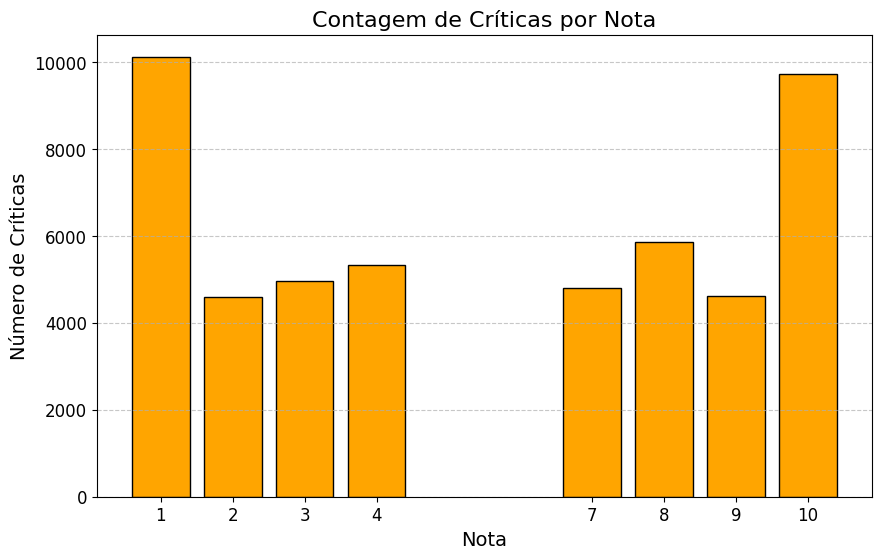

In [203]:
notas, contagem = np.unique(y, return_counts=True)

# Gráfico de barras para contagem de notas
plt.figure(figsize=(10, 6))
plt.bar(notas, contagem, color='orange', edgecolor='black')

# Configurações do gráfico
plt.title("Contagem de Críticas por Nota", fontsize=16)
plt.xlabel("Nota", fontsize=14)
plt.ylabel("Número de Críticas", fontsize=14)
plt.xticks(notas, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

In [204]:
# Visualizaçãp de uma crítica

print(Docs[0])
print("="*10)
print("Nota:", y[0])

Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty.
Nota: 10


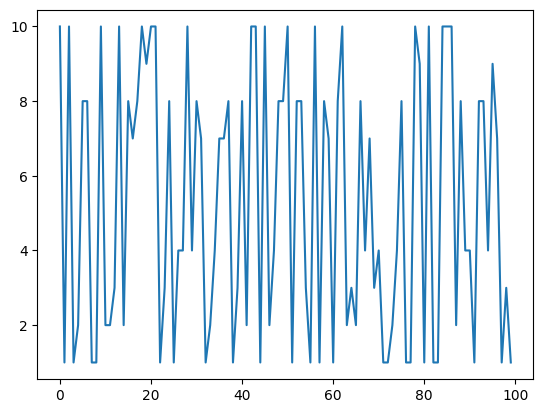

In [205]:
plt.plot(y[:100])

A partir do primeiro dos gráficos acima, é possível concluir que as críticas com nota 1 e 10 são mais frequentes do que críticas com as restantes avaliações. Já no segundo gráfico é possível perceber que os dados do conjunto de dados vêm baralhados e não organizado pela sua classificação, por exemplo, tornando desnecessário ter de baralhá-los.

# Construção do vocabulário

### Funções auxiliares

In [206]:
def saveDataPickle(data, fileName):
    """Função para guardar dados num Pickle

    Args:
        data: dados a guardar
        fileName: nome a dar ao ficheiro. (É PRECISO INCLUIR ``.p``)
    """
    with open(fileName, 'wb') as file:
        pickle.dump(data, file)

### Limpeza de texto

Inicialmente começou-se por fazer uma "limpeza" inicial dos textos para prepará-los para as tarefas de análise de dados seguintes. 

Primeiro, substituíram-se as quebras de linha HTML por espaços, facilitando a leitura dos textos. Em seguida, removeram-se todos os caracteres que não sejam letras alfabéticas (incluindo caracteres com acentos) usando expressões regulares, deixando apenas palavras compostas por letras. Isto vai ajudar a melhorar a qualidade dos dados, garantindo que os textos ficam num formato mais consistente.

In [207]:
# antes da limpeza tamanho do vocabulário = 101895

# remove as quebras de linha HTML
Docs=[doc.replace('<br />',' ') for doc in Docs] # remove as quebras de linha HTML
# remove tudo o que não seja chars alfabéticos
Docs=[re.sub(r'[^a-zA-Z\u00C0-\u00FF]+',' ', doc) for doc in Docs] 

#saveDataPickle(Docs, "DocsPreStem.p")

### Stemming

Em seguida, aplicou-se stemming aos textos para transformar as palavras na sua forma base, removendo sufixos e elementos que não alteram significativamente o significado da palavra. Para esta tarefa, foi utilizado o algoritmo `Snowball Stemmer`, devido à sua flexibilidade e ao facto de este conseguir lidar com diferentes idiomas.

Neste caso, o parâmetro ``"english"`` foi utilizado para indicar que o algoritmo deve aplicar regras específicas do idioma inglês, garantindo que o stemming seja realizado de forma consistente, tendo a língua inglesa por base (uma vez que as críticas que temos de classificar se encontram em inglês). Assim, cada palavra de cada texto é processada individualmente para obter a sua forma raiz. Por exemplo, palavras como "running", "runner" e "ran" serão reduzidas à mesma raiz ("run").

Com isso, conseguimos reduzir o tamanho do vocabulário, agrupando variações da mesma palavra para melhorar a eficiência e o desempenho dos algoritmos que vão ser utilizados mais à frente.

In [208]:
# Eliminar palavras parecidas
stemFunc = SnowballStemmer(language="english")
Docs = [' '.join([stemFunc.stem(w) for w in d.split()]) for d in Docs]

#saveDataPickle(X2, "DocsAfterStem.p")

### Conjuntos de treino/validação/teste

Tal como foi feito no trabalho 1, realizou-se a divisão dos dados em três conjuntos: treino, validação e teste.

Definiu-se que 50% dos dados serão usados para treino e 30% para validação, deixando os 20% restantes para a fase de teste. A divisão é feita de forma sequencial, ou seja, os primeiros 50% dos dados são guardados para o conjunto de treino, os próximos 30% para validação e o restante fica para teste. O objetivo da validação vai ser ajustar os hiperparâmetros do modelo, sem usar os dados de teste, que devem ser reservados apenas para avaliar o desempenho final do modelo. Com esta abordagem fica-se com uma avaliação mais robusta e imparcial da eficácia do modelo, prevenindo o overfitting e ajudando na seleção do melhor modelo.

In [209]:
# Divisão dos dados para treino e teste (80-20)
# Dividiu-se o conjunto de treino em Treino e Validação para encontrar os hiperparametros. (50-30)

# Proporções de cada conjunto
treino_ratio = 0.5
valid_ratio = 0.3

# Tamanhos para cada conjunto
treino_size = int(len(Docs) * treino_ratio)
valid_size = int(len(Docs) * valid_ratio)

# Dividir X e y entre treino, validação e teste
X_train = Docs[:treino_size]
y_train = y[:treino_size]

X_valid = Docs[treino_size:treino_size + valid_size]
y_valid = y[treino_size:treino_size + valid_size]

X_test = Docs[treino_size + valid_size:]
y_test = y[treino_size + valid_size:]

# Print dos tamanhos de cada conjunto
print("Conjunto de treino:", len(X_train), len(y_train))
print("Conjunto de validação:", len(X_valid), len(y_valid))
print("Conjunto de teste:", len(X_test), len(y_test))


Conjunto de treino: 25000 25000
Conjunto de validação: 15000 15000
Conjunto de teste: 10000 10000


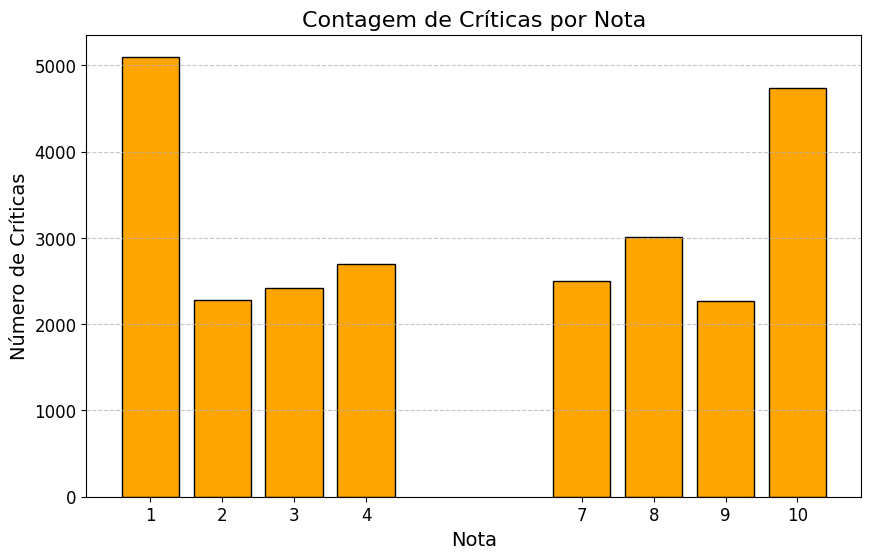

In [210]:
reviews = np.array(X_train)
scores = np.array(y_train)

# Contar o número de reviews por score
contagem_reviews_por_score = Counter(scores)

# Criar a saída organizada
saida_organizada = [f"{score}: {contagem}" for score, contagem in sorted(contagem_reviews_por_score.items())]

# Exibir o resultado
saida_organizada

notas, contagem = np.unique(y_train, return_counts=True)

# Gráfico de barras para contagem de notas
plt.figure(figsize=(10, 6))
plt.bar(notas, contagem, color='orange', edgecolor='black')

# Configurações do gráfico
plt.title("Contagem de Críticas por Nota", fontsize=16)
plt.xlabel("Nota", fontsize=14)
plt.ylabel("Número de Críticas", fontsize=14)
plt.xticks(notas, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

In [211]:
print(len(X_train))

25000


### Tfidf

O TF-IDF (Term Frequency-Inverse Document Frequency) é uma técnica de vetorização de texto utilizada para transformar textos em representações numéricas, tendo em conta a frequência com que uma palavra aparece num documento e a raridade dessa palavra em todo o conjunto de documentos. Esta técnica é útil para atribuir um peso maior a palavras que são importantes num documento, mas que aparecem com menor frequência no restante conjunto, ajudando a identificar os termos mais relevantes de cada crítica para a análise das críticas.

Utilizou-se o `TfidfVectorizer` para criar uma representação numérica dos textos, com os seguintes parâmetros:

`min_df=3`: Apenas as palavras que aparecem em pelo menos 3 documentos diferentes são incluídas no vocabulário. Este parâmetro filtra palavras extremamente raras que, devido à sua baixa ocorrência, têm pouca utilidade para a análise e podem introduzir ruído nos modelos.

`max_df=0.2`: Exclui palavras que aparecem em mais de 20% dos documentos, já que estas palavras tendem a ser muito comuns e pouco relevantes para a classificação (como "the", "is", "and").

`max_features=24000`: Limita o tamanho do vocabulário para os 24.000 termos mais relevantes. Este parâmetro ajuda a reduzir a dimensionalidade dos dados, mantendo apenas as palavras mais importantes e relevantes para os textos analisados. (O grupo tomou por regra atribuir ao vocabulário um valor igual ao do conjunto de treino menos 1000)

`token_pattern=r'\b\w\w+\b'`: Define que apenas palavras com pelo menos 2 caracteres serão consideradas para o vocabulário. Este padrão permite incluir palavras ligeiramente mais curtas.

`ngram_range=(1, 2)`: Considera combinações de palavras de tamanho 1 (uni gramas) e 2 (bigramas). Isto significa que, além de palavras isoladas, pares de palavras consecutivas (ex.: "good movie", "bad acting") também são incluídos no vocabulário, permitindo capturar relações contextuais entre alguns termos.

O vetor de características foi gerado apenas com os dados de treino (``fit(X_train)``), garantindo que o vocabulário seja ajustado apenas ao conjunto utilizado para treinar os modelos. Após aplicar o `TfidfVectorizer`, foi extraído o vocabulário resultante com o método `get_feature_names_out()`.

A escolha dos valores destes parâmetros foi escolhida ou pela lógica em alguns casos, ou através do teste com classificadores na fase seguinte e da análise dos melhores resultados, de forma a tentar encontrar a melhor combinação para analisar o nosso conjunto de dados.

Esta configuração garante uma representação mais eficiente dos textos, reduzindo o impacto das palavras irrelevantes e eliminando redundâncias de forma a manter apenas as características mais importantes para os algoritmos subsequentes.

In [212]:
# Defenir um padrão para as palavras (somente palavras com 2 ou mais caracteres)
word_padrao = r'\b\w\w+\b'

# Cria um vetor TF-IDF com as configurações definidas
tfidf = TfidfVectorizer(min_df=3, max_df=0.2, max_features=24000, token_pattern=word_padrao, ngram_range=(1, 2)).fit(X_train)

#saveDataPickle(tfidf, "tfidf_bow.p")

voc = tfidf.get_feature_names_out()
len(voc)

24000

In [213]:
# Ver parte do vocabulário
print(voc[15000:15500])

['person he' 'person in' 'person is' 'person life' 'person like'
 'person of' 'person that' 'person the' 'person think' 'person to'
 'person who' 'person would' 'persona' 'perspect' 'perspect of' 'persuad'
 'persuas' 'pertwe' 'pervers' 'pervert' 'pet' 'pete' 'peter' 'peter cush'
 'peter falk' 'peter jackson' 'peter seller' 'peterson' 'petti' 'pfeiffer'
 'pg' 'phantasm' 'phantom' 'phase' 'phenomen' 'phenomenon' 'phil' 'philip'
 'philipp' 'phillip' 'philo' 'philo vanc' 'philosoph' 'philosophi'
 'phoenix' 'phone' 'phone call' 'phoni' 'photo' 'photo of' 'photograph'
 'photograph and' 'photographi' 'photographi and' 'photographi is'
 'phrase' 'physic' 'physic and' 'pia' 'pianist' 'piano' 'pic' 'pick'
 'pick it' 'pick on' 'pick out' 'pick the' 'pick this' 'pick up'
 'pickford' 'pickup' 'pictur' 'pictur and' 'pictur but' 'pictur in'
 'pictur is' 'pictur it' 'pictur of' 'pictur that' 'pictur the'
 'pictur was' 'pie' 'piec' 'piec and' 'piec of' 'piec that' 'piec the'
 'pierc' 'pierc brosnan' 'p

### Representação tfidf

In [214]:
# matriz com linhas = ao número de documentos e colunas = ao tamanho do vocabulário
X_train1 = tfidf.transform(X_train)
print(X_train1.shape)

X_valid1 = tfidf.transform(X_valid)
print(X_valid1.shape)

(25000, 24000)
(15000, 24000)


# Classificação e Regressão

Como classificador para fazer a classificação dos dados recorreu-se á `regressão logística`, que também já tinha sido abordado no tp1. A Regressão Logística é um método de classificação supervisionada que vai medir a probabilidade de uma instância pertencer a uma determinada classe. É particularmente eficaz para resolver problemas de classificação binária, mas também pode ser estendido para problemas multiclasse, como é o caso das críticas de cinema.

O modelo é inicialmente treinado com os dados de treino utilizando o método fit, que ajusta os parâmetros do classificador com base nas características dos textos e nas respetivas pontuações. Durante o processo de treino, foi realizada a otimização dos hiperparâmetros do modelo, com o objetivo de melhorar a sua precisão e a capacidade de generalização. A busca pelos melhores hiperparâmetros assegura que o modelo esteja bem ajustado às especificidades dos dados. Após o treino, a avaliação do desempenho é feita no conjunto de validação, utilizando o método predict, que prevê as classes (pontuações) para os textos de validação.

Para obter os melhores resultados foram escolhidos estes parâmetros para o classificador:

`multi_class='ovr'`: Indica que a abordagem utilizada é a **"one-vs-rest"** (um contra o resto). Esta abordagem transforma um problema multiclasse em vários classificadores binários, onde cada classificador é treinado para distinguir uma classe específica das restantes. Essa configuração é necessária porque os dados em questão possuem múltiplas classes de saída, exigindo que o modelo consiga identificar qual a classe mais provável entre várias possibilidades. Na classificação, o modelo calcula a probabilidade de um dado pertencer a cada classe (usando a função sigmoide da regressão logística), e no fim a classe com a maior probabilidade é atribuída como sendo a classe a que esse dado pertence.

`solver="lbfgs"`: O solver (algoritmo de otimização) utilizado é o "Limited-memory Broyden–Fletcher–Goldfarb–Shanno" (LBFGS), que é eficiente para conjuntos de dados médios e grandes, especialmente em problemas multiclasse. Este método otimiza a função de custo para encontrar os melhores coeficientes do modelo, garantindo estabilidade e uma maior rapidez no processo.

`class_weight="balanced"`: Este parâmetro ajusta automaticamente os pesos de cada classe com base na frequência das mesmas no conjunto de treino. Classes menos representadas recebem maior peso, o que ajuda o modelo a lidar com dados desbalanceados, garantindo que as previsões não favoreçam as classes mais frequentes. Este parâmetro acaba por ser bastante útil uma vez que o conjunto de dados apresentava um grande desequilíbrio no número de críticas por classe, onde algumas das classes possuíam um número muito maior de críticas quando comparadas com outras.

In [215]:
# Define o modelo de Regressão Logística.
clf = LogisticRegression(multi_class='ovr', solver="lbfgs", class_weight="balanced")

# Treina o modelo usando os dados de treino (X_train1) e as respectivas classes (y_train).
clf.fit(X_train1, y_train)

# Avaliação no conjunto de validação
y_pred_valid = clf.predict(X_valid1)

print(classification_report(y_valid, y_pred_valid))

C:\Users\migue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.63      0.69      0.66      3033
           2       0.21      0.16      0.18      1408
           3       0.24      0.23      0.24      1503
           4       0.31      0.34      0.33      1615
           7       0.30      0.30      0.30      1378
           8       0.27      0.25      0.26      1698
           9       0.21      0.17      0.19      1401
          10       0.56      0.62      0.59      2964

    accuracy                           0.41     15000
   macro avg       0.34      0.35      0.34     15000
weighted avg       0.39      0.41      0.40     15000



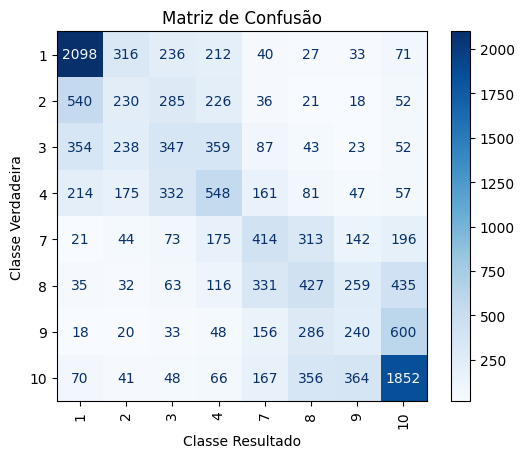

In [216]:
conf_matrix = confusion_matrix(y_valid, y_pred_valid)

# Gerar e exibir a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_valid))

# Exibir a matriz
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de Confusão")
plt.xlabel("Classe Resultado")
plt.ylabel("Classe Verdadeira")
plt.show()

A matriz de confusão permite analisar o desempenho do classificador em prever as diferentes classes (pontuações das críticas). Na diagonal principal da matriz, encontram-se os valores que representam as previsões corretas, ou seja, os casos em que a classe prevista corresponde à classe verdadeira. Nota-se que as classes 1 e 10 têm um acerto mais destacado, com o maior número de acertos na diagonal (2098 e 1852, respetivamente), indicando que o modelo tem maior facilidade em identificar estas pontuações extremas. 

Por outro lado, para as classes intermédias, há uma maior dispersão dos valores fora da diagonal, refletindo uma tendência do modelo em confundir estas pontuações com outras próximas, o que tendo em conta o tipo de dados acaba por ser natural acontecer. Mesmo para nós humanos é díficil distinguir uma crítica nota 8 e 9, por exemplo. 

Embora existam algumas dispersões nos valores fora da diagonal, especialmente nas classes intermédias, o desempenho geral do classificador é aceitável, considerando que os valores na diagonal principal são significativamente superiores às restantes previsões incorretas. De um modo geral, observa-se que a precisão decresce ligeiramente nas classes intermédias, enquanto nas extremas o acerto é mais consistente.

Após encontrados os hiperparâmetros para melhorar o desempenho do modelo passou-se à fase de teste. Nesta fase, a divisão dos dados foi alterada para incluir apenas dois conjuntos principais: treino e teste. O conjunto de validação foi removido (com o valor valid_ratio = 0.0), e o foco passou a ser treinar o modelo com 80% dos dados e testar seu desempenho nos 20% restantes. Assim, o modelo será avaliado utilizando apenas o conjunto de teste, sem ter a validação separada. 

In [217]:
# Proporções de cada conjunto
treino_ratio = 0.8
valid_ratio = 0.0

# Tamanhos para cada conjunto
treino_size = int(len(Docs) * treino_ratio)
valid_size = int(len(Docs) * valid_ratio)

# Dividir X e y entre treino e teste
X_train = Docs[:treino_size]
y_trainT = y[:treino_size]

X_test = Docs[treino_size + valid_size:]
y_test = y[treino_size + valid_size:]

# Print dos tamanhos de cada conjunto
print("Conjunto de treino:", len(X_train), len(y_trainT))
print("Conjunto de validação:", len(X_valid), len(y_valid))
print("Conjunto de teste:", len(X_test), len(y_test))


Conjunto de treino: 40000 40000
Conjunto de validação: 15000 15000
Conjunto de teste: 10000 10000


In [218]:
print(len(X_train))

40000


Como as dimensões do conjunto de treino foram aumentadas, foi necessário ajustar novamente o vocabulário para ficar de acordo com os novos dados.

In [219]:
word_padrao = r'\b\w\w+\b'

tfidfT = TfidfVectorizer(min_df=3, max_df=0.2, max_features=39000, token_pattern=word_padrao, ngram_range=(1, 2)).fit(X_train)

#saveDataPickle(tfidf, "tfidf_bow.p")

voc = tfidfT.get_feature_names_out()
len(voc)

39000

In [220]:
# matriz com linhas = ao número de documentos e colunas = ao tamanho do vocabulário
X_train1T = tfidfT.transform(X_train)
print(X_train1T.shape)

# matriz com linhas = ao número de documentos e colunas = ao tamanho do vocabulário
X_test1 = tfidfT.transform(X_test)
print(X_test1.shape)

(40000, 39000)
(10000, 39000)


In [221]:
clf.fit(X_train1T, y_trainT)

# Avaliação no conjunto de validação
y_pred_test = clf.predict(X_test1)
print(classification_report(y_test, y_pred_test))

C:\Users\migue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.64      0.71      0.67      1989
           2       0.24      0.18      0.21       894
           3       0.29      0.26      0.27      1038
           4       0.34      0.36      0.35      1020
           7       0.30      0.34      0.32       929
           8       0.28      0.26      0.26      1152
           9       0.22      0.16      0.18       943
          10       0.57      0.65      0.61      2035

    accuracy                           0.43     10000
   macro avg       0.36      0.36      0.36     10000
weighted avg       0.41      0.43      0.42     10000



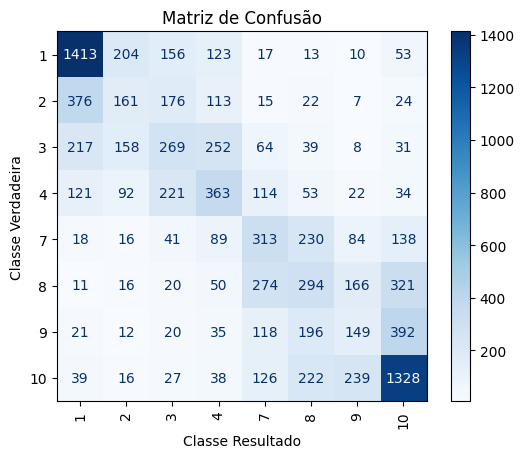

In [222]:
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Gerar e exibir a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_test))

# Configurações de exibição

disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de Confusão")
plt.xlabel("Classe Resultado")
plt.ylabel("Classe Verdadeira")
plt.show()

Neste último teste, obteve-se um resultado bastante semelhante ao primeiro, embora se verifique uma melhora na percentagem de acertos. Ainda é visível uma dispersão nas críticas intermédias, sobretudo daquelas cujo valor se aproxima mais de 1 e de 10.

Contudo, tal como referido na análise da matriz anterior, esta dispersão é normal dada a natureza dos dados e, deixando este fator de lado, os valores obtidos são satisfatórios.

# Regressão

Concluida a parte da classificação passou-se então á regressão. A regressão é utilizada para prever um valor contínuo com base numa ou mais variáveis independentes. Enquanto um classificador prevê categorias ou classes, um regressor prevê valores numéricos contínuos, como a altura de uma pessoa, o preço de uma casa ou neste caso irá a pontuação contínua de críticas. A regressão ajuda a encontrar relações entre os dados e a construir modelos que fazem previsões baseadas nessas relações.

O regressor escolhido foi o `Ridge Regression`. Este classificador inclui um termo de regularização que é útil para reduzir o risco de overfitting. Possui um parâmetro `alpha` que controla a intensidade da regularização: valores maiores de alpha aumentam a penalização para coeficientes altos no modelo, reduzindo o impacto de características menos relevantes.

No caso dos dados do trabalho, que possuem um número elevado de variáveis correlacionadas entre si, a Regressão Ridge é uma escolha adequada. A regularização ajuda a lidar com essas correlações e melhora a robustez do modelo ao prever valores contínuos. O Ridge Regression possui um parâmetro alpha que controla a intensidade dessa regularização. O valor ideal de alpha é importante para equilibrar o erro causado por um modelo simples demais e o erro causado por um modelo que se ajusta demasiado aos dados de treino, provocando o overfitting.

Para testar diferentes valores de alpha na Regressão Ridge, de forma a encontrar o melhor valor (aquele que minimiza o erro médio quadrático - MSE e maximiza o coeficiente R^2), foi criada a função ``test_ridge_alphas``. A função treina um modelo Ridge para cada valor de alpha fornecido, calcula o desempenho no conjunto de validação em termos de MSE e R^2, e retorna o alpha ideal, o menor MSE encontrado, o maior R^2, e os valores de desempenho para todos os alphas testados. Desta forma, é possível ajustar o modelo Ridge para obter os melhores valores, garantindo um equilíbrio entre a capacidade preditiva e a regularização.

In [223]:
def test_ridge_alphas(X_train, y_train, X_valid, y_valid, alphas):
    # Inicializa o melhor alpha como None e define o MSE inicial como um valor muito alto (infinito)
    best_alpha = None
    best_mse = float('inf')  # Inicializando com um valor muito alto
    mse_values = []  # Lista para armazenar os valores de MSE para cada alpha testado
    
    for alpha in alphas: # Percorre os diferentes valores de alpha fornecidos
        # Criar o modelo Ridge com o valor de alpha
        regressor = Ridge(alpha=alpha)
        
        # Treina o modelo com os dados de treino
        regressor.fit(X_train, y_train)
        
        # Faz previsões contínuas no conjunto de validação
        y_pred_continuous = regressor.predict(X_valid)
        print("R2 coef:", regressor.score(X_valid, y_valid), "| alpha = ", alpha)

        # Calcula o erro médio quadrático (MSE) para as previsões
        mse = mean_squared_error(y_valid, y_pred_continuous)
        mse_values.append(mse)
        
        # Verifica se o MSE atual é menor que o melhor MSE encontrado até agora
        if mse < best_mse:
            # Atualiza o melhor MSE
            best_mse = mse 
            # Atualiza o melhor alpha
            best_alpha = alpha 
    
   # Retorna o melhor alpha encontrado, o menor MSE e todos os MSEs para análise
    return best_alpha, best_mse, mse_values

# Conjunto de Validação

In [224]:
# Testar vários valores de alpha
alphas = np.logspace(-6, 6, 13)  # Exemplo de alphas, de 10^-6 a 10^6
best_alphaV, best_mseV, mse_valuesV = test_ridge_alphas(X_train1, y_train, X_valid1, y_valid, alphas)
# Exibir o melhor alpha e o MSE
print(f"\nMelhor alpha: {best_alphaV}")
print(f"Melhor MSE: {best_mseV}")

R2 coef: -6.978342575694086 | alpha =  1e-06
R2 coef: -6.741865843479079 | alpha =  1e-05
R2 coef: -5.222721480415939 | alpha =  0.0001
R2 coef: -2.1061988865315957 | alpha =  0.001
R2 coef: -0.21071952031124108 | alpha =  0.01
R2 coef: 0.4500293755448982 | alpha =  0.1
R2 coef: 0.6278521960129624 | alpha =  1.0
R2 coef: 0.5891317588760807 | alpha =  10.0
R2 coef: 0.27522899463527417 | alpha =  100.0
R2 coef: 0.04248245845014442 | alpha =  1000.0
R2 coef: 0.004483545368178743 | alpha =  10000.0
R2 coef: 0.0004452544523454449 | alpha =  100000.0
R2 coef: 3.889467875095587e-05 | alpha =  1000000.0

Melhor alpha: 1.0
Melhor MSE: 4.529963009382416


In [225]:
# Cria um modelo de Regressão Ridge com o parâmetro alpha=1, que controla a intensidade da regularização.
regressor = Ridge(alpha=1)
# Treina o modelo Ridge nos dados de treino (X_train1 e y_train), ajustando os coeficientes do modelo para minimizar o erro regularizado.
regressor.fit(X_train1, y_train)
# Fazer previsões no conjunto de validação
y_pred_continuous = regressor.predict(X_valid1)

Erro Quadrático Médio (MSE): O MSE é uma métrica que mede o erro médio entre os valores reais (``y_valid``) e os valores previstos (`y_pred_continuous`). Calcula a média dos quadrados das diferenças entre os valores reais e previstos. Um valor menor de MSE indica que o modelo está a prever os dados com maior precisão.

Coeficiente de Determinação (R²): O R² mede a proporção da variância dos dados que é explicada pelo modelo. Varia entre 0 e 1. Um valor próximo de 1 indica que o modelo é muito bom a explicar os dados, enquanto valores baixos sugerem que o modelo não está a capturar bem o padrão dos dados.

In [226]:
# Avaliar o desempenho com Mean Squared Error
mse = mean_squared_error(y_valid, y_pred_continuous)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print("R2 coef:", regressor.score(X_valid1, y_valid))

Erro Quadrático Médio (MSE): 4.5300
R2 coef: 0.6278521960129624


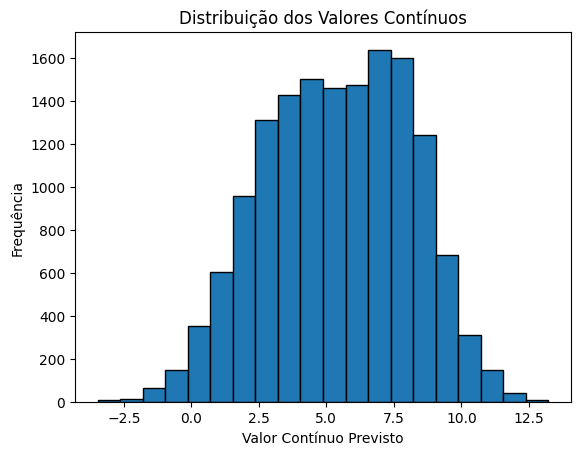

In [227]:
# Visualizar a distribuição dos valores contínuos previstos
plt.hist(y_pred_continuous, bins=20, edgecolor='black')
plt.xlabel('Valor Contínuo Previsto')
plt.ylabel('Frequência')
plt.title('Distribuição dos Valores Contínuos')
plt.show()

Nesta fase passou-se à conversão de valores contínuos para classes discretas. Isto é necessária, porque, neste caso, o modelo de regressão Ridge prevê valores contínuos, mas o problema original é de classificação, onde as críticas pertencem a classes específicas (notas de 1 a 4 e de 7 a 10). Assim, garantimos que os resultados possam ser comparados com as classes originais.

Para fazer esta transformação foram escolhidos valores para serem limiares de quantificação e o seu valor foi definido à mão, após a observação do impacto que tinham na matriz de confusão. 

In [228]:
# Converter valores contínuos para as classes discretas válidas
def continuous_to_discrete(y_pred):
    y_discrete = []
    for y in y_pred:
        if y <= 1.9:  # Classe 1
            y_discrete.append(1)
        elif y <= 3.3:  # Classe 2
            y_discrete.append(2)
        elif y <= 4.4:  # Classe 3
            y_discrete.append(3)
        elif y <= 5.5:  # Classe 4
            y_discrete.append(4)
        elif y <= 6.7:  # Classe 7
            y_discrete.append(7)
        elif y <= 7.75:  # Classe 8
            y_discrete.append(8)
        elif y <= 8.87:  # Classe 9
            y_discrete.append(9)
        else:  # Classe 10
            y_discrete.append(10)
    return np.array(y_discrete)

# Converter as previsões contínuas
y_pred_discrete = continuous_to_discrete(y_pred_continuous)
print(np.unique(y_pred_discrete))

[ 1  2  3  4  7  8  9 10]


Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.63      0.32      0.42      3033
           2       0.20      0.30      0.24      1408
           3       0.22      0.28      0.25      1503
           4       0.23      0.28      0.25      1615
           7       0.18      0.28      0.22      1378
           8       0.23      0.28      0.25      1698
           9       0.20      0.27      0.23      1401
          10       0.57      0.27      0.37      2964

    accuracy                           0.29     15000
   macro avg       0.31      0.29      0.28     15000
weighted avg       0.37      0.29      0.30     15000

R2 Coeficientes (Treino) 0.8343321979562637
R2 Coeficientes (Teste) 0.6278521960129624 

[[966 958 581 365 124  27   7   5]
 [291 425 343 221 105  18   5   0]
 [182 380 420 303 165  33  18   2]
 [ 94 285 406 455 268  84  20   3]
 [  2  16  62 216 382 371 235  94]
 [  0   9  36 142 402 476 408 225]
 [  0   4  15 101 249

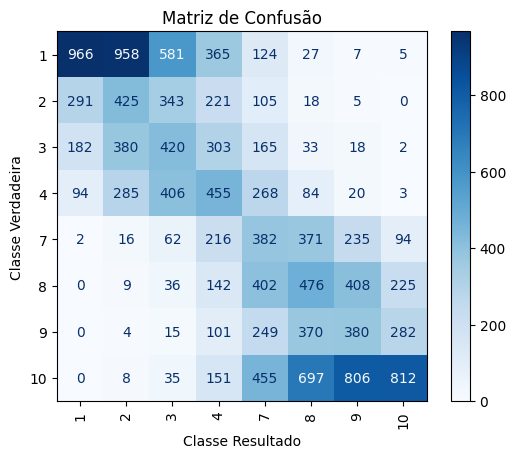

In [229]:
# Avaliar o modelo com valores discretos
print("Relatório de Classificação:\n", classification_report(y_valid, y_pred_discrete))
print("R2 Coeficientes (Treino)", regressor.score(X_train1, y_train))
print("R2 Coeficientes (Teste)", regressor.score(X_valid1, y_valid), "\n")

conf_matrix=confusion_matrix(y_valid, y_pred_discrete)
print(conf_matrix)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_valid))

# exibição dos resultados
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de Confusão")
plt.xlabel("Classe Resultado")
plt.ylabel("Classe Verdadeira")
plt.show()


A matriz de confusão apresentada permite avaliar o desempenho do modelo ao prever as classes discretas (pontuações das críticas). Nesta matriz, observa-se que as classes extremas, como 1 e 10, apresentam números significativos de acertos (966 e 812, respetivamente), indicando que o modelo consegue identificar com maior precisão essas pontuações.

No entanto, há uma notável dispersão dos valores fora da diagonal para as classes intermédias, refletindo uma dificuldade do modelo em diferenciar essas pontuações próximas. Por exemplo, a classe 8 apresenta um grande número de previsões incorretas, sendo frequentemente confundida com as classes 7 e 9, o que é compreensível, dado o caráter contínuo e subjetivo dos dados.

Apesar dessas dispersões, os valores ao longo da diagonal ainda são consideráveis, o que demonstra um desempenho geral aceitável do modelo. Essa tendência de maior precisão nas classes extremas e maior confusão nas classes intermédias é comum em problemas de classificação em que há uma sobreposição natural entre categorias adjacentes. Esta tendencia também já tinha sido vista nos testes realizados na fase anterior, do classificador.

# Conjunto de Teste

Nesta fase, passou-se à análise dos resultados com o conjunto de teste. À semelhança do que tinha sido feito na classificação, a divisão dos dados foi alterada para incluir apenas dois conjuntos principais: treino e teste, sendo que o treino é formado por treino + validação.

In [230]:
best_alpha, best_mse, mse_values = test_ridge_alphas(X_train1T, y_trainT, X_test1, y_test, alphas)
# Exibir o melhor alpha e o MSE
print(f"\nMelhor alpha: {best_alpha}")
print(f"Melhor MSE: {best_mse}")

R2 coef: -13.11012709240366 | alpha =  1e-06
R2 coef: -11.632117417797724 | alpha =  1e-05
R2 coef: -6.363673125029655 | alpha =  0.0001
R2 coef: -1.8547681172191397 | alpha =  0.001
R2 coef: -0.0696923694171745 | alpha =  0.01
R2 coef: 0.5103431105909282 | alpha =  0.1
R2 coef: 0.6668240139828236 | alpha =  1.0
R2 coef: 0.632339876259328 | alpha =  10.0
R2 coef: 0.34279772167659817 | alpha =  100.0
R2 coef: 0.05913183793709864 | alpha =  1000.0
R2 coef: 0.00599674390577476 | alpha =  10000.0
R2 coef: 0.00022554671912922153 | alpha =  100000.0
R2 coef: -0.0003565343716065428 | alpha =  1000000.0

Melhor alpha: 1.0
Melhor MSE: 4.0658873941886515


In [231]:
regressor = Ridge(alpha=1)  # Ridge é mais robusto com regularização
regressor.fit(X_train1T, y_trainT)

# Fazer previsões no conjunto de validação
y_pred_continuous = regressor.predict(X_test1)

In [232]:
# Avaliar o desempenho com Mean Squared Error
mse = mean_squared_error(y_test, y_pred_continuous)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print("R2 coef:", regressor.score(X_test1, y_test))

Erro Quadrático Médio (MSE): 4.0659
R2 coef: 0.6668240139828236


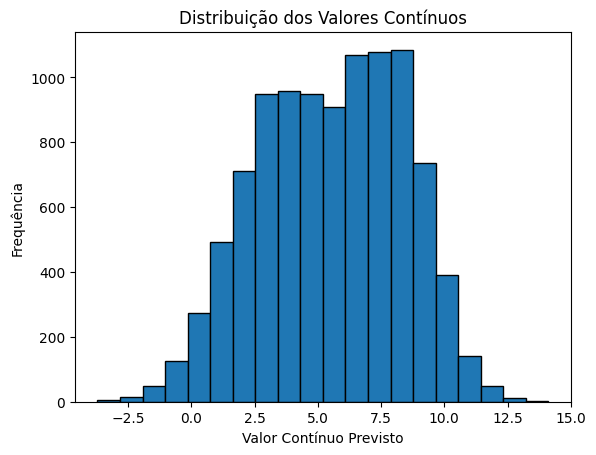

In [233]:
# Visualizar a distribuição dos valores contínuos previstos
plt.hist(y_pred_continuous, bins=20, edgecolor='black')
plt.xlabel('Valor Contínuo Previsto')
plt.ylabel('Frequência')
plt.title('Distribuição dos Valores Contínuos')
plt.show()

In [234]:
# Converter valores contínuos para as classes discretas válidas
def continuous_to_discrete(y_pred):
    y_discrete = []
    for y in y_pred:
        if y <= 1.85:  # Classe 1
            y_discrete.append(1)
        elif y <= 3.3:  # Classe 2
            y_discrete.append(2)
        elif y <= 4.4:  # Classe 3
            y_discrete.append(3)
        elif y <= 5.5:  # Classe 4
            y_discrete.append(4)
        elif y <= 6.7:  # Classe 7
            y_discrete.append(7)
        elif y <= 7.85:  # Classe 8
            y_discrete.append(8)
        elif y <= 9.00:  # Classe 9
            y_discrete.append(9)
        else:  # Classe 10
            y_discrete.append(10)
    return np.array(y_discrete)

# Converter as previsões contínuas
y_pred_discrete = continuous_to_discrete(y_pred_continuous)
print(np.unique(y_pred_discrete))

[ 1  2  3  4  7  8  9 10]


Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.63      0.35      0.45      1989
           2       0.21      0.32      0.25       894
           3       0.23      0.26      0.25      1038
           4       0.24      0.28      0.26      1020
           7       0.21      0.31      0.25       929
           8       0.24      0.29      0.26      1152
           9       0.19      0.27      0.22       943
          10       0.57      0.31      0.40      2035

    accuracy                           0.30     10000
   macro avg       0.32      0.30      0.29     10000
weighted avg       0.37      0.30      0.32     10000

R2 Coeficientes (Treino) 0.8376913783171368
R2 Coeficientes (Teste) 0.6668240139828236 

[[705 620 377 200  65  15   6   1]
 [212 286 207 131  44  10   3   1]
 [144 253 274 230 108  26   1   2]
 [ 62 172 268 284 187  36  10   1]
 [  0  10  26 111 286 259 166  71]
 [  0   3  16  74 236 335 311 177]
 [  0   5   8  59 150

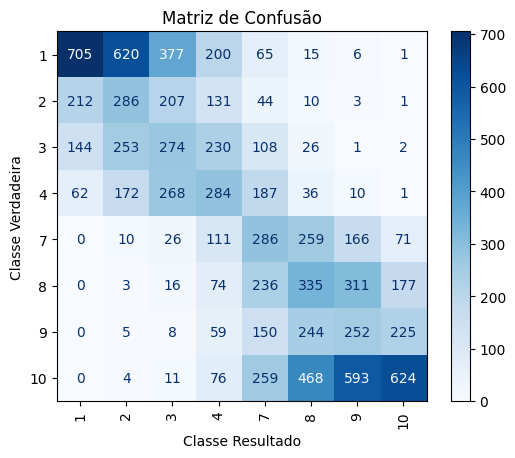

In [235]:
# Avaliar o modelo usando valores discretos
print("Relatório de Classificação:\n", classification_report(y_test, y_pred_discrete))
print("R2 Coeficientes (Treino)", regressor.score(X_train1T, y_trainT))
print("R2 Coeficientes (Teste)", regressor.score(X_test1, y_test), "\n")

conf_matrix=confusion_matrix(y_test, y_pred_discrete)
print(conf_matrix)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_test))

# Plot da matriz
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de Confusão")
plt.xlabel("Classe Resultado")
plt.ylabel("Classe Verdadeira")
plt.show()


A probilidade de acertos aumentou ligeiramente, face ao teste entre o conjunto de teste e de validação. Os limiares também foram daqui definidos à mão, procurando evidenciar os valores da diagonal da matriz para aumentar a quantidade de acertos efetuados pelo modelo.

Dado o facto do regressor prever os valores de forma contínua, era de esperar que o seu desempenho fosse inferior ao do classificador, o que de facto acabou por acontecer. Se o classificador treina e prevê os valores de forma discreta e apresenta uma falha nas previsões efetuadas, era de esperar que com o regressor se perdesse algum rigor na medição, pois ainda é necessário converter os valores contínuos em discretos.

# Clustering

Foram selecionadas 25000 críticas para o processo de clustering, garantindo uma amostra significativa para análise e um tempo de execução dos algoritmos razoável.
Foi utilizada a técnica de Truncated Singular Value Decomposition (SVD) para reduzir a dimensionalidade dos dados TF-IDF para 3 componentes principais. Isso permite representar as críticas de forma compacta, preservando as relações mais relevantes entre os documentos. Optou-se usar o SVD, pois esta técnica trabalha já com matrizes do tipo sparse, como são os dados que resultam do Tf-idf.

In [236]:
num_criticas = 25000

svd = TruncatedSVD(n_components=3, random_state=42)  # Reduz para 50 dimensões
X_train_reduced = svd.fit_transform(X_train1T[:num_criticas, :])


Com base nos dados reduzidos, aplicou-se o método de *ward linkage* para calcular a similaridade entre as críticas e criar uma estrutura hierárquica. Criou-se o seguinte dendrograma para visualizar esta hierarquia, que também ajuda na identificação do número de clusters mais adequados.

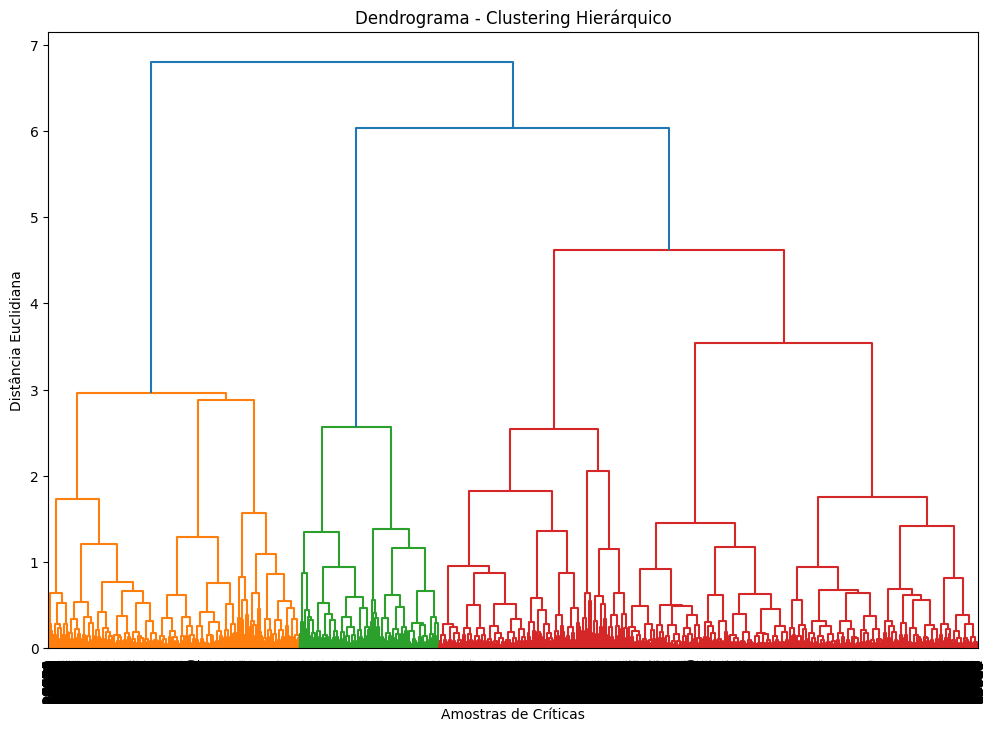

In [237]:
linkage_matrix = linkage(X_train_reduced, method='ward')

# Criar o dendrograma
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendrograma - Clustering Hierárquico')
plt.xlabel('Amostras de Críticas')
plt.ylabel('Distância Euclidiana')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Com base no dendrograma acima, podemos ver que um corte 3 seria um bom número de clusters.

Aplicou-se o algoritmo K-Means para agrupar as críticas de acordo com suas similaridades. Cada crítica foi atribuída a um cluster com base nas suas características reduzidas.

In [238]:
# Escolha o número de clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_train1[:num_criticas, :])

Para cada cluster, foram calculados os valores médios de TF-IDF das palavras associadas às críticas nele agrupadas. As palavras com maior valor médio de TF-IDF em cada cluster foram identificadas como representativas do tópico mais frequente.

Contudo, é possível que embora relativamente distintas, são palavras um pouco genéricas, impedindo assim de definir um tópico específico para cada cluster.

In [239]:
# Calcular os valores médios de TF-IDF para cada cluster
tfidf_array = X_train1[:num_criticas, :].toarray()
cluster_tfidf_means = np.array([tfidf_array[cluster_labels == i].mean(axis=0) for i in range(num_clusters)])

# Identificar as palavras mais importantes em cada cluster
tokens = tfidf.get_feature_names_out()
for i in range(num_clusters):
    top_words_idx = cluster_tfidf_means[i].argsort()[-10:][::-1]
    top_words = [tokens[j] for j in top_words_idx]
    print(f"Cluster {i}: Palavras mais importantes: {top_words}")

Cluster 0: Palavras mais importantes: ['ever', 'funni', 'your', 'movi is', 've', 'did', 'to see', 'better', 'worst', 'watch it']
Cluster 1: Palavras mais importantes: ['life', 'perform', 'man', 'as the', 'best', 'role', 'two', 'young', 'famili', 'beauti']
Cluster 2: Palavras mais importantes: ['horror', 'tri', 'guy', 'off', 'where', 're', 'whi', 'kill', 'littl', 'over']


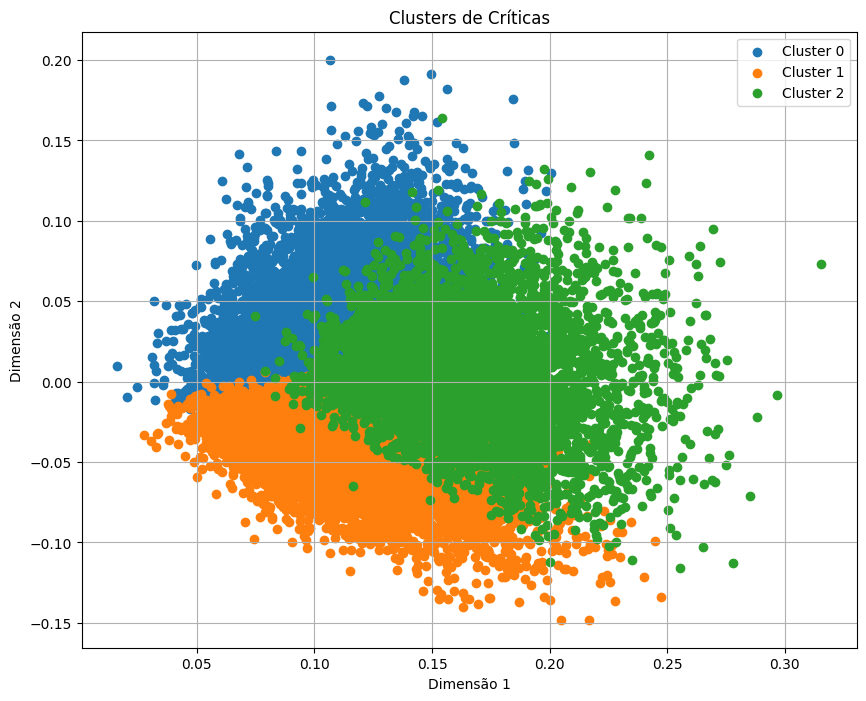

In [240]:
# Plotar os clusters
plt.figure(figsize=(10, 8))
for i in range(num_clusters):
    plt.scatter(X_train_reduced[cluster_labels == i, 0], X_train_reduced[cluster_labels == i, 1], label=f"Cluster {i}")
plt.legend()
plt.title("Clusters de Críticas")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.grid(True)
plt.show()


No plot acima onde estão apresentados os clusters, é possível verificar que os três clusters são bem distintos, embora ainda exista alguma sobre posição entre eles.

# Conslusão

Com este trabalho o grupo aprofundou os seus conhecimentos na análise e trabalho com dados de texto, mais especificamente com as criticas de cinema. 

Percebeu-se a importância da defenição correta dos parâmetros para a construção do vocabulário, por exemplo antes da escolha do snowball stemmer, tinha-se optado pelo PorterStemmer e a diferença de resultado entre ambos foi significativa. O Tf-idf também se revelou um ponto importante na defenição do vocabulário, onde o valor de cada parâmetro apresentava um grande impacto no resultado final (por exemplo, a utilização de bigramas e o parâmetro max-features revelaram-se importantes e melhoraram bastante os resultados obtidos).

Antes de se optar pelo LogisticRegression de forma defenitiva, foram também testados outros classificadores como alternativa (RandomForest, MultinomialNB e SVC contudo os dois primeiros dependiam bastante do numero de criticas de cada classe, e o SVC apresentava um tempo de execução demasiado elevado) porém este foi o que permitiu obter uma precisão mais alta na classificação das criticas e num tempo de processamento razoavél. 

Relativamente à regressão, optou-se pelo Ridge após o teste com LinearRegression e com o Lasso. Uma vez que o Ridge depende do parâmetro alpha, testou-se este modelo de regressão com vários valores neste parâmetro com o objetivo de encontrar o valor que permitisse obter os melhores resultados de MSE e R2. No final desta fase, surgiram algumas complicações com a defenição dos limiares de classificação para cada classe. Contornou-se este problema ao defenir manualmente esses limiares com o objetivo de destacar os valores da diagonal da matriz de confusão.

Por fim, na última fase deste trabalho realizou-se o clustering de uma amostra do conjunto de dados. Começou-se por retirar dimensões para facilitar a sua análise e passou-se á elaboração de um dendrograma e, a partir dele, defeniu-se o número de clusters a utilizar. O método de clustering utilizado foi o K-means com base nos valores mais frequentes de Tf-idf. Esta secção foi onde surgiram mais problemas, pois o grupo sentiu mais dificuldade a separar a criticas de acordo com um topico especifico. Para tentar resolver este problema tentou-se elaborar um novo vocabulario com o objetivo de destacar palavras que remetessem a um tópico especifico, mas sem grande sucesso.

Em suma, tendo em conta todos os resultados obtidos acreditamos que embora não sejam os ideais; contudo, tendo por base os dados do IMDB, consideramos que sejam resultados aceitáveis.

# Bibliografia

- Slides disponibilizados via Moodle pelo Professor Gonçalo Marques

- Classificador LogisticRegression
  - Documentação do LR: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html
  - Video sobre o LR: https://www.youtube.com/watch?v=EYXSve6T5BU

- Regressor Ridge:
  - Documentação do Ridge: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.Ridge.html
  - Videos sobre o Ridge: 
    - https://www.youtube.com/watch?v=Q81RR3yKn30
    - https://www.youtube.com/watch?v=Xm2C_gTAl8c

- SVD:
  - https://scikit-learn.org/1.5/modules/generated/sklearn.decomposition.TruncatedSVD.html
